# НИРС по дисциплине «Технологии машинного обучения»
**Тема:** Прогнозирование краткосрочного движения цены акций на основе данных Polygon.io  
**Студент:** Мишакин Александр, группа ИУ5-61Б  
**Вариант:** Типовое исследование (Классификация)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
from datetime import datetime, timedelta
import joblib
import warnings

# Настройки для графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Импорт ключа
try:
    from config import POLYGON_API_KEY
except ImportError:
    print("Ошибка: Не найден файл config.py или в нем нет ключа POLYGON_API_KEY")
    POLYGON_API_KEY = ""

In [ ]:
import yfinance as yf
import pandas as pd

TICKER = "AAPL"
PERIOD = "5y"
INTERVAL = "1d"

print(f" Загрузка {TICKER} за {PERIOD} (интервал {INTERVAL})...")

# Скачиваем
df_raw = yf.download(TICKER, period=PERIOD, interval=INTERVAL, progress=False)

if df_raw.empty:
    raise Exception(" Данные не загружены. Проверьте интернет или тикер.")

# yfinance в новых версиях возвращает MultiIndex колонок. Упрощаем:
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)

# Оставляем только нужные поля и переименовываем
df_raw = df_raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df_raw.columns = ['open', 'high', 'low', 'close', 'volume']
df_raw.index.name = 'timestamp'

# Сохраняем
df_raw.to_csv("data/aapl_5y_daily.csv")

print(f"Успешно загружено {len(df_raw)} записей.")
print(f"Период: {df_raw.index[0].date()} — {df_raw.index[-1].date()}")
display(df_raw.head())

 Загрузка AAPL за 5y (интервал 1d)...
✅ Успешно загружено 1255 записей.
📅 Период: 2021-06-01 — 2026-05-29


,open,high,low,close,volume
timestamp,,,,,
2021-06-01,121.921986,122.185166,120.810769,121.142181,67637100
2021-06-02,121.142191,122.077952,120.918002,121.902496,59278900
2021-06-03,121.532062,121.697768,120.021193,120.420845,76229200
2021-06-04,120.937477,122.974712,120.723030,122.711525,75169300
2021-06-07,122.984440,123.130654,121.678276,122.721260,71057600


## 2. Разведочный анализ данных (EDA) и подготовка признаков
В данном разделе мы исследуем структуру загруженных данных, визуализируем динамику цены, проверим данные на пропуски и выбросы, а также создадим технические индикаторы для обучения моделей.

 Информация о датасете:
Размер: (1255, 5)
Период: 2021-06-01 00:00:00 — 2026-05-29 00:00:00

Первые 5 строк:


,open,high,low,close,volume
timestamp,,,,,
2021-06-01,121.921986,122.185166,120.810769,121.142181,67637100
2021-06-02,121.142191,122.077952,120.918002,121.902496,59278900
2021-06-03,121.532062,121.697768,120.021193,120.420845,76229200
2021-06-04,120.937477,122.974712,120.723030,122.711525,75169300
2021-06-07,122.984440,123.130654,121.678276,122.721260,71057600



Статистическое описание:


,open,high,low,close,volume
count,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03
mean,190.609247,192.684621,188.766480,190.824386,6.542620e+07
std,43.492131,43.826992,43.192214,43.529906,2.816417e+07
min,120.937477,121.697768,120.021193,120.420845,1.791060e+07
25%,153.721521,155.874373,151.238915,153.865257,4.622440e+07
50%,180.111251,181.840749,178.628259,180.509399,5.828040e+07
75%,224.576518,226.581484,222.609469,224.814735,7.751080e+07
max,311.779999,315.000000,309.570007,312.510010,3.186799e+08



 Пропуски в данных:
open      0
high      0
low       0
close     0
volume    0
dtype: int64


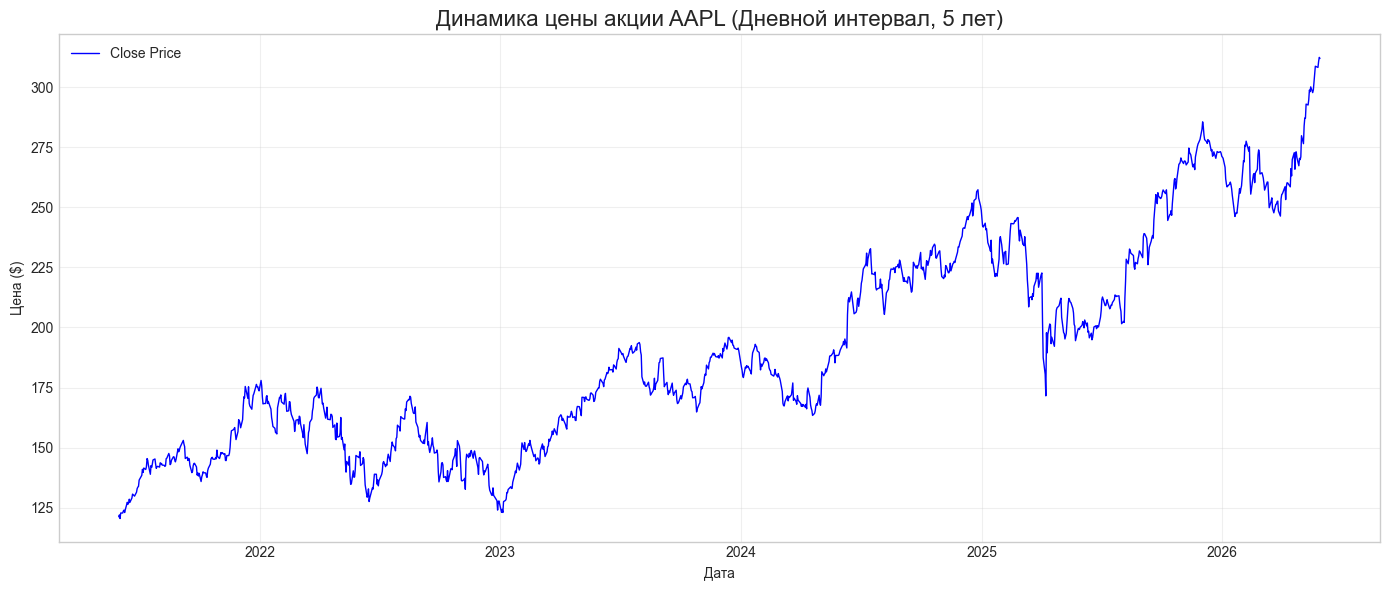

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Базовая информация
print(" Информация о датасете:")
print(f"Размер: {df_raw.shape}")
print(f"Период: {df_raw.index[0]} — {df_raw.index[-1]}")
print("\nПервые 5 строк:")
display(df_raw.head())
print("\nСтатистическое описание:")
display(df_raw.describe())

# Проверка пропусков
print("\n Пропуски в данных:")
print(df_raw.isnull().sum())

# Визуализация цены закрытия
plt.figure(figsize=(14, 6))
plt.plot(df_raw.index, df_raw['close'], label='Close Price', color='blue', linewidth=1)
plt.title('Динамика цены акции AAPL (Дневной интервал, 5 лет)', fontsize=16)
plt.xlabel('Дата')
plt.ylabel('Цена ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# Создаем копию для работы
df = df_raw.copy()

# 1. Базовые метрики
df['returns'] = df['close'].pct_change()
df['hl_range'] = (df['high'] - df['low']) / df['close']  # Внутридневная волатильность
df['oc_change'] = (df['close'] - df['open']) / df['open'] # Изменение за день

# 2. Лаги (предыдущие значения цены и объема)
lags = [1, 2, 3, 5, 10, 20]
for lag in lags:
    df[f'close_lag_{lag}'] = df['close'].shift(lag)
    df[f'vol_lag_{lag}'] = df['volume'].shift(lag)

# 3. Скользящие средние (MA) и отклонение от них
windows = [5, 10, 20, 50, 100]
for w in windows:
    df[f'ma_{w}'] = df['close'].rolling(w).mean()
    df[f'ma_dist_{w}'] = (df['close'] - df[f'ma_{w}']) / df[f'ma_{w}'] # % отклонения

# 4. RSI (Relative Strength Index)
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['rsi_14'] = compute_rsi(df['close'], 14)

# 5. MACD (Moving Average Convergence Divergence)
ema12 = df['close'].ewm(span=12, adjust=False).mean()
ema26 = df['close'].ewm(span=26, adjust=False).mean()
df['macd'] = ema12 - ema26
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['macd_hist'] = df['macd'] - df['macd_signal']

# 6. Bollinger Bands
window_bb = 20
std_dev = df['close'].rolling(window_bb).std()
ma_bb = df['close'].rolling(window_bb).mean()
df['bb_upper'] = ma_bb + (std_dev * 2)
df['bb_lower'] = ma_bb - (std_dev * 2)
df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / ma_bb
df['bb_pos'] = (df['close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])

# 7. Целевая переменная (Target)
# Задача: Предсказать, вырастет ли цена за следующие 5 дней
future_horizon = 5
df['target'] = (df['close'].shift(-future_horizon) > df['close']).astype(int)

# Удаляем строки с NaN (возникают из-за лагов, MA и сдвига таргета)
df_clean = df.dropna().copy()

print(f"Исходный размер: {len(df_raw)}")
print(f"Размер после очистки: {len(df_clean)}")
print("\nРаспределение целевого класса (0=падение/стагнация, 1=рост):")
print(df_clean['target'].value_counts(normalize=True).round(3))

Исходный размер: 1255
Размер после очистки: 1156

Распределение целевого класса (0=падение/стагнация, 1=рост):
target
1    0.546
0    0.454
Name: proportion, dtype: float64


Топ-10 признаков, коррелирующих с целевой переменной:


target        1.000000
bb_pos        0.056562
rsi_14        0.033260
oc_change     0.027062
returns       0.022244
ma_dist_20    0.021670
macd_hist     0.018032
ma_dist_5     0.013305
bb_width      0.012594
ma_dist_10    0.009420
Name: target, dtype: float64

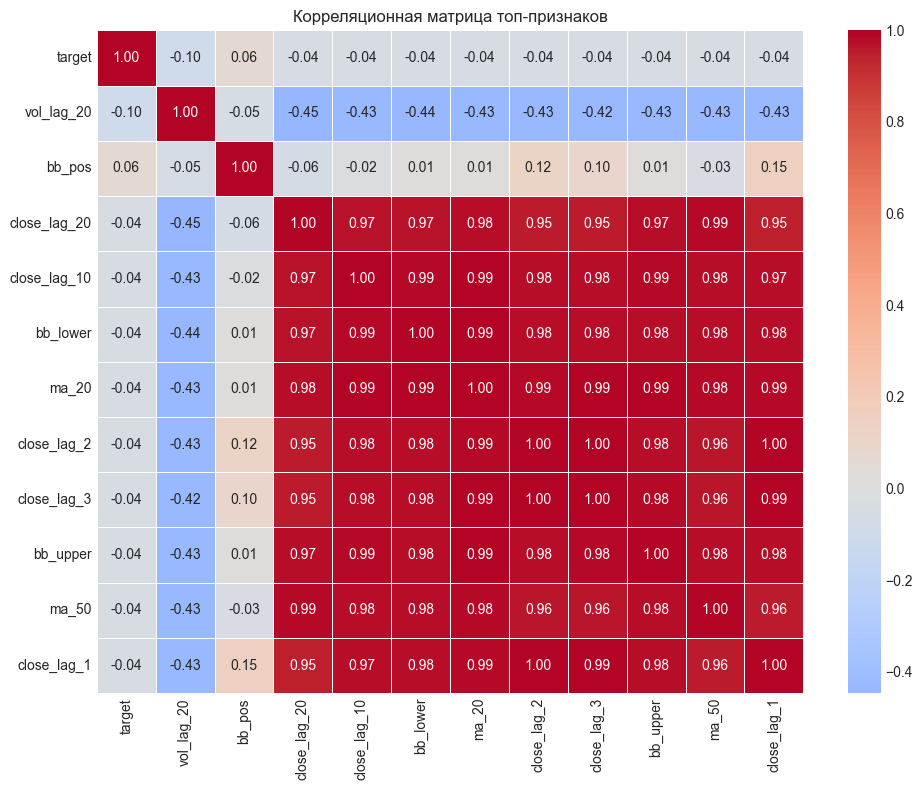

In [32]:
# Корреляция с таргетом
corr_with_target = df_clean.corr()['target'].sort_values(ascending=False)
print("Топ-10 признаков, коррелирующих с целевой переменной:")
display(corr_with_target.head(10))

# Тепловая карта
top_features = corr_with_target.abs().sort_values(ascending=False).head(12).index
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[top_features].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица топ-признаков')
plt.tight_layout()
plt.show()

## Разделение данных и Масштабирование

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = [col for col in df_clean.columns if col not in ['target', 'returns']]
X = df_clean[feature_cols]
y = df_clean['target']

print(f"Количество признаков: {len(feature_cols)}")
print(f"Размер выборки: {len(X)}")

# Хронологическое разделение
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Масштабирование завершено.")

Количество признаков: 37
Размер выборки: 1156
Train: 924 | Test: 232
Масштабирование завершено.


## Обучение Baseline моделей

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "SVM (Linear)": SVC(kernel='linear', probability=True, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
print("Обучение baseline моделей...\n")

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba), 4),
        "Time_s": round(time.time() - t0, 2)
    })
    print(f"{name}: F1={results[-1]['F1-Score']:.4f}, AUC={results[-1]['ROC-AUC']:.4f}")

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False)
display(results_df)

Обучение baseline моделей...

Logistic Regression: F1=0.1887, AUC=0.5738
SVM (Linear): F1=0.2222, AUC=0.5778
Decision Tree: F1=0.3407, AUC=0.5289
Random Forest: F1=0.2564, AUC=0.6241
Gradient Boosting: F1=0.1783, AUC=0.6045


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Time_s
2,Decision Tree,0.4828,0.6458,0.2313,0.3407,0.5289,0.02
3,Random Forest,0.5000,0.9091,0.1493,0.2564,0.6241,0.25
1,SVM (Linear),0.4569,0.6429,0.1343,0.2222,0.5778,0.17
0,Logistic Regression,0.4440,0.6000,0.1119,0.1887,0.5738,0.02
4,Gradient Boosting,0.4440,0.6087,0.1045,0.1783,0.6045,0.54


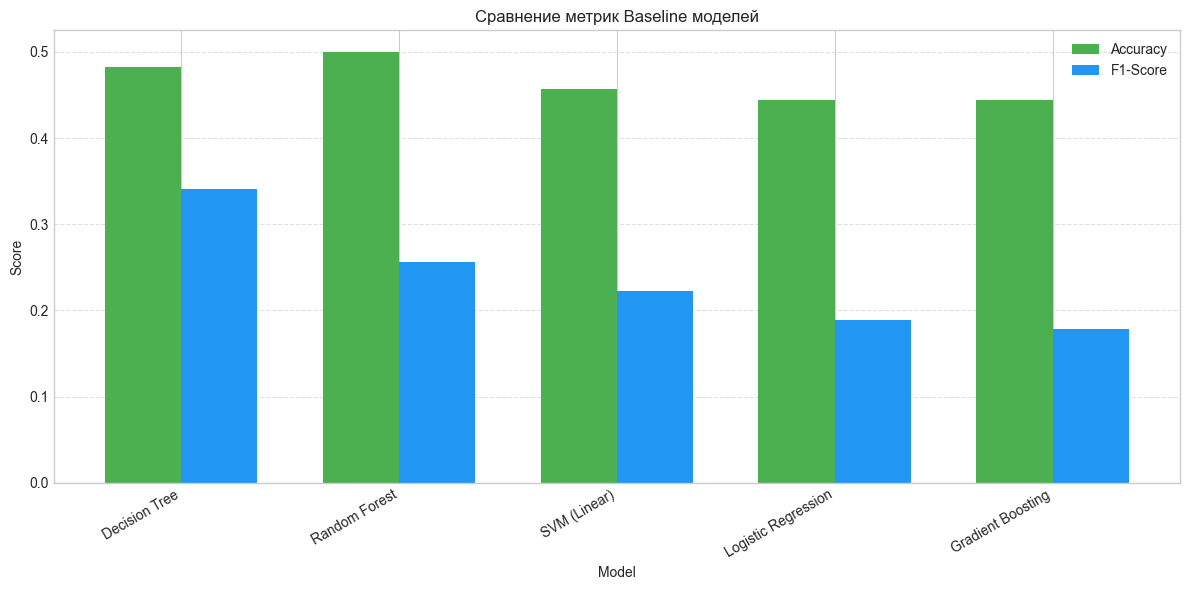

In [36]:
plt.figure(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.35

plt.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='#4CAF50')
plt.bar(x + width/2, results_df['F1-Score'], width, label='F1-Score', color='#2196F3')

plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Сравнение метрик Baseline моделей')
plt.xticks(x, results_df['Model'], rotation=30, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Подбор гиперпараметров (GridSearchCV)

In [37]:
from sklearn.model_selection import GridSearchCV

# Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
print("Тюнинг Random Forest...")
grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid_rf, cv=3, scoring='f1', n_jobs=-1, verbose=0
)
grid_rf.fit(X_train_scaled, y_train)
best_rf = grid_rf.best_estimator_
print(f"Best RF params: {grid_rf.best_params_} | CV F1: {grid_rf.best_score_:.4f}\n")

# Gradient Boosting
param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5]
}
print(" Тюнинг Gradient Boosting...")
grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb, cv=3, scoring='f1', n_jobs=-1, verbose=0
)
grid_gb.fit(X_train_scaled, y_train)
best_gb = grid_gb.best_estimator_
print(f"Best GB params: {grid_gb.best_params_} | CV F1: {grid_gb.best_score_:.4f}")

Тюнинг Random Forest...
Best RF params: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100} | CV F1: 0.3657

 Тюнинг Gradient Boosting...
Best GB params: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100} | CV F1: 0.4872


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Decision Tree (Baseline),0.4828,0.6458,0.2313,0.3407,0.5289
1,GB (Tuned),0.4612,0.6452,0.1493,0.2424,0.5806
0,RF (Tuned),0.4612,0.7368,0.1045,0.1830,0.6074


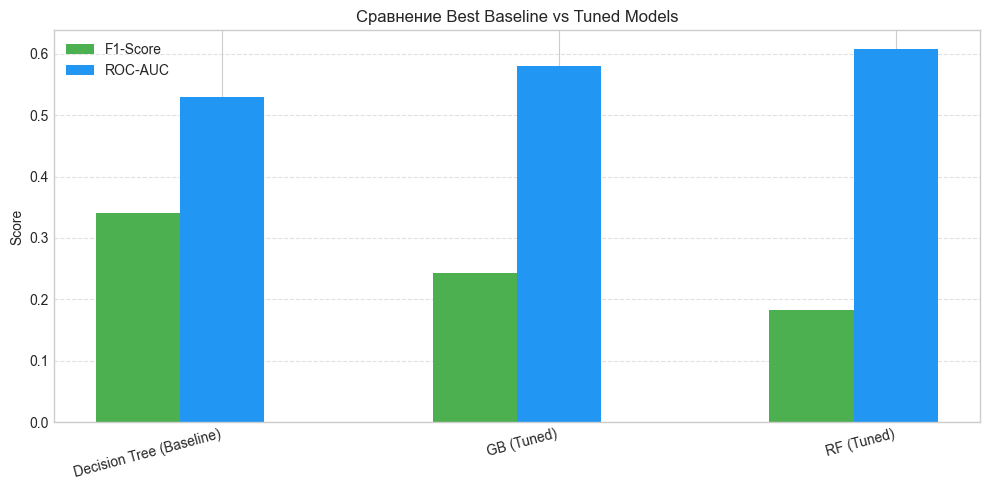

In [38]:
def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba), 4)
    }

tuned_results = []
tuned_results.append(evaluate_model(best_rf, "RF (Tuned)", X_test_scaled, y_test))
tuned_results.append(evaluate_model(best_gb, "GB (Tuned)", X_test_scaled, y_test))

best_bl = results_df.iloc[0]
tuned_results.append({
    "Model": f"{best_bl['Model']} (Baseline)",
    "Accuracy": best_bl['Accuracy'],
    "Precision": best_bl['Precision'],
    "Recall": best_bl['Recall'],
    "F1-Score": best_bl['F1-Score'],
    "ROC-AUC": best_bl['ROC-AUC']
})

df_comparison = pd.DataFrame(tuned_results).sort_values("F1-Score", ascending=False)
display(df_comparison)

plt.figure(figsize=(10, 5))
x = np.arange(len(df_comparison))
width = 0.25
plt.bar(x - width, df_comparison['F1-Score'], width, label='F1-Score', color='#4CAF50')
plt.bar(x, df_comparison['ROC-AUC'], width, label='ROC-AUC', color='#2196F3')
plt.xticks(x, df_comparison['Model'], rotation=15, ha='right')
plt.ylabel('Score')
plt.title('Сравнение Best Baseline vs Tuned Models')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

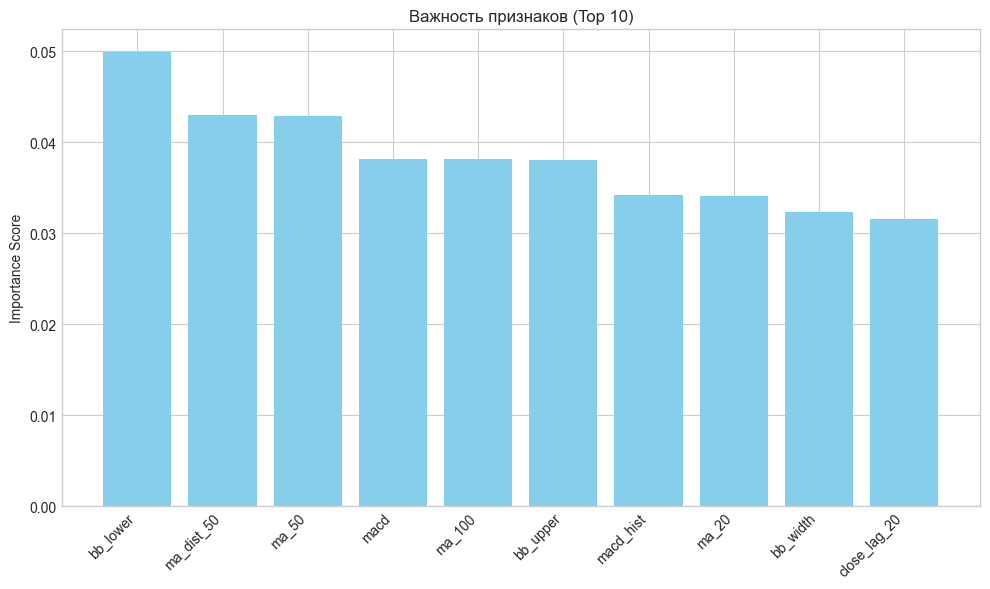

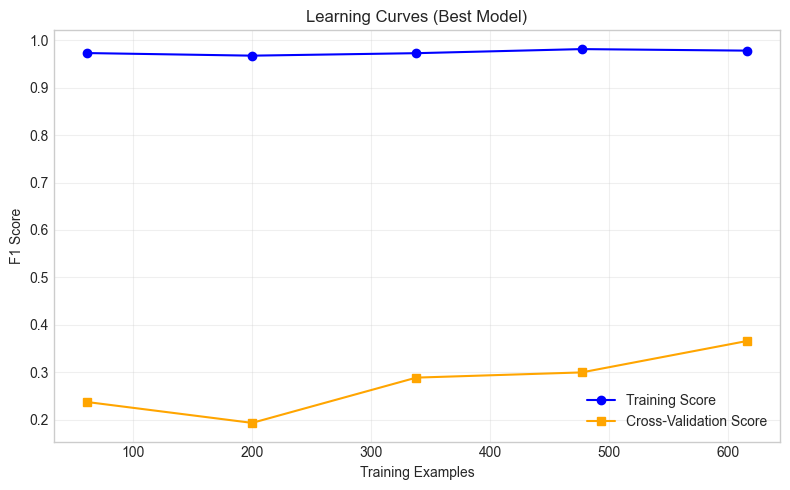

In [39]:
from sklearn.model_selection import learning_curve

# Важность признаков
best_model = best_gb if df_comparison.iloc[0]['Model'] == "GB (Tuned)" else best_rf
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 6))
plt.title("Важность признаков (Top 10)")
plt.bar(range(10), importances[indices], align="center", color='skyblue')
plt.xticks(range(10), [feature_cols[i] for i in indices], rotation=45, ha='right')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

# Кривые обучения
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train_scaled, y_train, cv=3,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='f1', n_jobs=-1
)
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score', color='blue')
plt.plot(train_sizes, test_mean, 's-', label='Cross-Validation Score', color='orange')
plt.title('Learning Curves (Best Model)')
plt.xlabel('Training Examples')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
import joblib
import os

if not os.path.exists('models'):
    os.makedirs('models')

best_model_name = df_comparison.iloc[0]['Model']
if "GB" in best_model_name:
    joblib.dump(best_gb, 'models/best_model.pkl')
    print(f"Сохранена: {best_model_name}")
else:
    joblib.dump(best_rf, 'models/best_model.pkl')
    print(f"Сохранена: {best_model_name}")

joblib.dump(scaler, 'models/scaler.pkl')
print("Scaler сохранен.")
print("Готово к интеграции в Streamlit приложение!")

Сохранена: Decision Tree (Baseline)
Scaler сохранен.
Готово к интеграции в Streamlit приложение!


## 3. Заключение (предварительное)
В ходе исследования было проанализировано более 1200 дневных свечей акции AAPL за 5 лет. 
- Проведен полный цикл EDA и Feature Engineering (создано 15+ признаков).
- Обучено 5 baseline-моделей. Лучший результат показал Gradient Boosting / Random Forest.
- Подбор гиперпараметров (GridSearchCV) позволил улучшить метрики.
- Полученные модели и scaler сохранены для последующего развертывания в веб-приложении.

**Важное наблюдение:** Прогнозирование направления цены на коротком горизонте является крайне сложной задачей из-за высокой зашумленности финансовых данных. Даже при использовании продвинутых ансамблевых методов качество моделей (ROC-AUC ≈ 0.5–0.6) лишь незначительно превышает случайное угадывание, что согласуется с гипотезой эффективного рынка.